In [1]:
import os
import numpy as np
import pandas as pd

from src import Dataloader,SIR_PF

import matplotlib.pyplot as plt
from  scipy.optimize import curve_fit

c:\Users\bbritoschiele\Documents\PHD_files\2026\adaptive_bayesian_filter_prognostics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Visualize Nick's data

In [2]:
dataloader = Dataloader(os.path.join('data_NE'), 'stiffness_red')
dataloader.data_folder

{1: 'DIC_Specimen01.csv',
 5: 'DIC_Specimen05.csv',
 6: 'DIC_Specimen06.csv',
 7: 'DIC_Specimen07.csv',
 8: 'DIC_Specimen08.csv',
 9: 'DIC_Specimen09.csv',
 10: 'DIC_Specimen10.csv',
 11: 'DIC_Specimen11.csv',
 12: 'DIC_Specimen12.csv'}

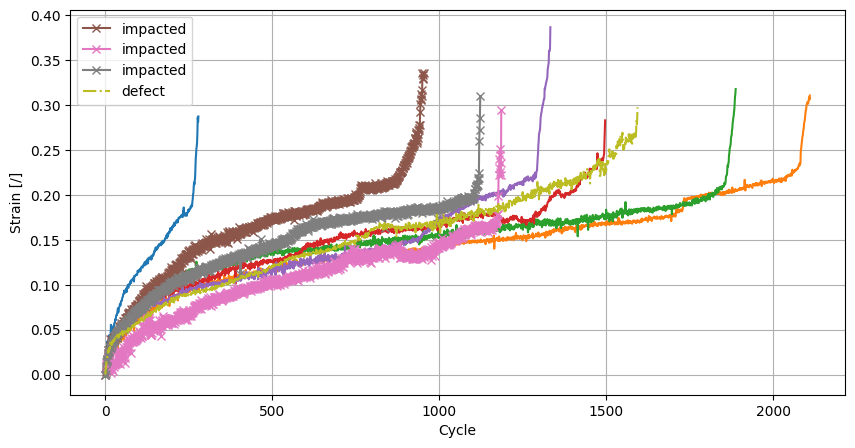

In [3]:
# f = dic_data[0]
plt.figure(figsize=(10,5))
# plt.title('Axial strain DIC data')
plt.xlabel('Cycle')
plt.ylabel('Strain [/]')
plt.grid()


for f in dataloader.data_folder.keys():    
    if f in [9,11,10]:
        plt.plot(dataloader.load_id(f)[0],'-x', label = 'impacted')
    elif f == 12:
        plt.plot(dataloader.load_id(f)[0],'-.', label = 'defect')
    else:
        plt.plot(dataloader.load_id(f)[0])
plt.legend()
plt.show()



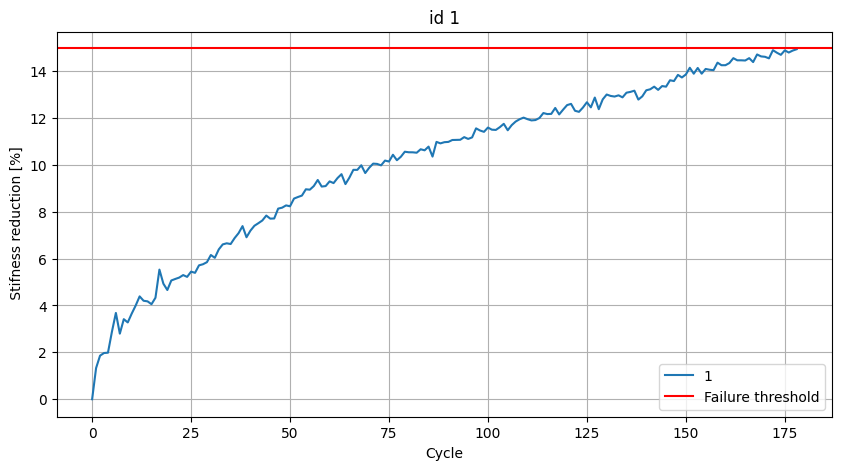

In [4]:
dataloader.thresh = 0.15
dataloader.hi = 'stiffness_red'

# plt.title('Axial strain change DIC data')
for f in dataloader.data_folder.keys():
    plt.figure(figsize=(10,5))
    plt.title(f'id {f}')    
    plt.xlabel('Cycle')
    plt.ylabel(' Stifness reduction [%]')
    plt.grid()

    if f in [9,11,10]:
        plt.plot(dataloader.load_id(f)[0]*100,'-x', label = 'impacted')
    elif f == 12:
        plt.plot(dataloader.load_id(f)[0]*100,'-.', label = 'defect')
    else:
        plt.plot(dataloader.load_id(f)[0]*100, label = f)

    plt.axhline(dataloader.thresh*100, color = 'r', label = 'Failure threshold')

    plt.legend()
    # plt.savefig('HI_data.eps')
    plt.show()
    break

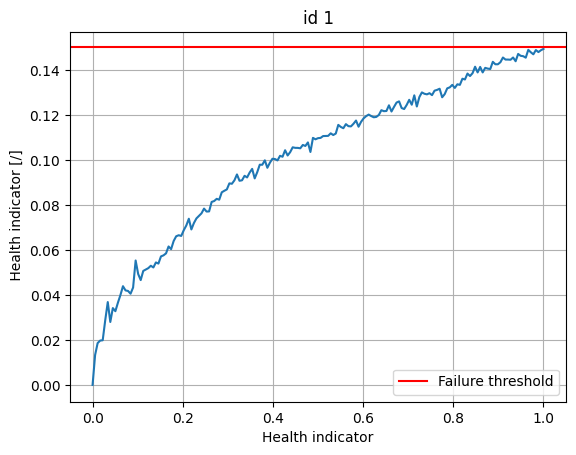

In [5]:
# plt.figure(figsize=(10,5))
# plt.title('Axial strain change DIC data')
for f in dataloader.data_folder.keys():    
    plt.xlabel('Health indicator')
    plt.ylabel(' Health indicator [/]')
    plt.grid()

# for f in dataloader.data_folder.keys():    
    plt.title(f'id {f}')
    
    data = dataloader.load_id(f)[0]
    h = np.linspace(0,1, len(data))
    
    
    if f in [9,11,10]:
        plt.plot(h,data,'-x', label = 'impacted')
    elif f == 12:
        plt.plot(h,data,'-.', label = 'defect')
    else:
        plt.plot(h,data)

    plt.axhline(dataloader.thresh, color = 'r', label = 'Failure threshold')

    plt.legend()
    plt.show()
    break

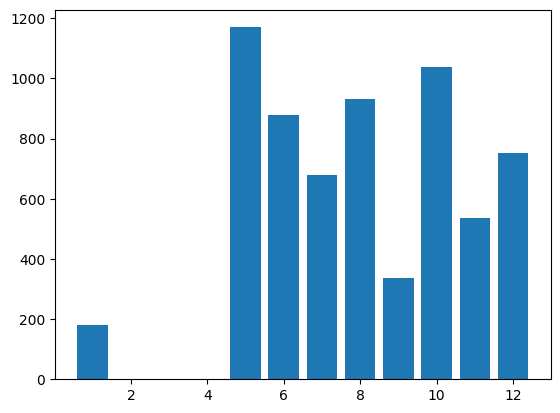

In [6]:
liftimes = np.array([len(dataloader.load_id(id)[0]) for id in dataloader.ids])

plt.figure()
plt.bar(dataloader.ids, liftimes)
plt.show()

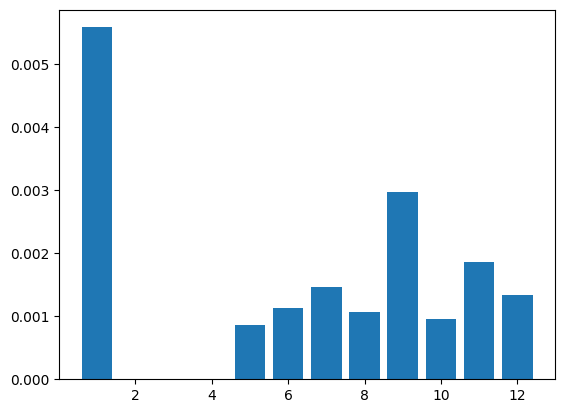

In [8]:
rates = np.array([dataloader.load_id(id)[1] for id in dataloader.ids])

plt.figure()
plt.bar(dataloader.ids, rates)
plt.show()

In [11]:
liftimes = np.array([len(dataloader.load_id(id)[0]) for id in dataloader.ids])
print(liftimes.mean())
print(liftimes.std())

585.6666666666666
356.7574650780119


In [ ]:
len(dataloader.ids)

In [ ]:
def poli_fn(hi, a,b,c):
    return a*hi**3+b*hi**2+c*hi


# f_train = [1,2,5,6, 7]
# f_test = [8,9,10,11]

f_train = np.random.choice(list(dataloader.ids), 7, replace=False )
f_test = [i  for i in dataloader.ids if not i in f_train]



data_train = []
hi_train = []
for f in f_train:
    data = dataloader.load_id(f)
    data_train.extend(data)
    hi_train.extend(np.linspace(0,1, len(data)))
    






msg= curve_fit(poli_fn, hi_train,data_train,p0=(1,1,1), full_output=False)
popt = msg[0]
print(msg)
# if msg[-1] is int:
#     print(msg)

h_ = np.linspace(0,1,100)
y_ = poli_fn(h_, *popt)




plt.figure()


# f = 10
for f in f_test:
    data = dataloader.load_id(f)
    h = np.linspace(0,1,len(data))
    plt.scatter(h, data, color = 'b', alpha = 0.2)
for f in f_train:
    data = dataloader.load_id(f)
    h = np.linspace(0,1,len(data))
    plt.scatter(h, data, color = 'g', alpha = 0.2)
    
plt.plot(h_,y_, color = 'r')
plt.grid()
# plt.ylim([0,dataloader.thresh])
plt.show()

In [ ]:
damage_rate = []
for f in dataloader.ids:
    data = dataloader.load_id(f)
    damage_rate.append(1/len(data))
    
plt.figure()
plt.bar(dataloader.ids, damage_rate)
plt.show()

### Implement the PF

In [ ]:
# Load data
dataloader = Dataloader('data_NE', 'percentual', thresh=0.2)

In [ ]:
# Fit obs_eq
def poli_fn(hi, a,b,c):
    return a*hi**3+b*hi**2+c*hi


# f_train = [1,2,5,6, 7]
# f_test = [8,9,10,11]

f_train = np.random.choice(list(dataloader.ids), 7, replace=False )
f_test = [i  for i in dataloader.ids if not i in f_train]



data_train = []
hi_train = []
for f in f_train:
    data = dataloader.load_id(f)
    data_train.extend(data)
    hi_train.extend(np.linspace(0,1, len(data)))
    
msg= curve_fit(poli_fn, hi_train,data_train,p0=(1,1,1), full_output=False)
popt = msg[0]
print(msg)


In [ ]:
# get noise level and damage accumulation rates
errors = []
for f in f_train:
    data = dataloader.load_id(f)
    h = np.linspace(0,1,len(data))
    y = poli_fn(h, *popt)
    errors.extend(data-y)
print('error mean and std:\t', np.mean(errors), np.std(errors))

damage_rate = []
for f in dataloader.ids:
    data = dataloader.load_id(f)
    damage_rate.append(1/len(data))
    
print('damage acc mean and std:\t', np.mean(damage_rate), np.std(damage_rate))



In [ ]:
# Setup the update functinos for the PF 
N_particles = 100
obs_std = np.std(errors)

obs_eq = lambda x: poli_fn(x, *popt)
state_eq = lambda x, p: x+p + np.random.normal(0,1e-3, N_particles)
param_eq = lambda p: p + np.random.normal(0, 1e-3, N_particles)

# Setup the priors
x_0 = np.random.uniform(0, 1e-6, N_particles) # We should be confident that it starts at 0 -> No past uncertainty
p_0 = np.random.normal(np.mean(damage_rate),np.std(damage_rate), N_particles)



In [ ]:
# Instance de PF
particle_filter = SIR_PF(obs_eq, state_eq, param_eq, N_particles, obs_std)
particle_filter.init_state(x_0, p_0)

In [ ]:
data_test = dataloader.load_id(f_test[0])
for y in data_test:
    particle_filter.update(y)
    print(particle_filter.mean())
    

### Visualize optuna results

In [1]:
import numpy as np

In [2]:
x = np.random.uniform(0,1, (3,5))
w = np.random.uniform(0,0.001,(3,5))
y = 0.5*np.ones((3,1))
w = np.stack([w_/w_.sum() for w_ in w])

In [3]:
x

array([[0.89292308, 0.85007677, 0.63938961, 0.88122235, 0.1196482 ],
       [0.15600824, 0.66343829, 0.09946722, 0.1576341 , 0.17362596],
       [0.38382005, 0.56076558, 0.48325713, 0.60869155, 0.81493445]])

In [4]:
x_add = np.concatenate([x,np.zeros((3,1)),y], axis = 1)
w_add= np.concatenate([w,np.zeros((3,1)),np.zeros((3,1))], axis = 1)

In [5]:

inds = np.argsort(x_add, axis=1)
x_sorted = np.take_along_axis(x_add, inds, axis=1)
w_sorted = np.take_along_axis(w_add, inds, axis=1).cumsum(axis = 1)
x_sorted

array([[0.        , 0.1196482 , 0.5       , 0.63938961, 0.85007677,
        0.88122235, 0.89292308],
       [0.        , 0.09946722, 0.15600824, 0.1576341 , 0.17362596,
        0.5       , 0.66343829],
       [0.        , 0.38382005, 0.48325713, 0.5       , 0.56076558,
        0.60869155, 0.81493445]])

In [6]:
w_sorted

array([[0.        , 0.20136593, 0.20136593, 0.36135706, 0.66155799,
        0.9884454 , 1.        ],
       [0.        , 0.28237541, 0.62204107, 0.65339482, 0.90591096,
        0.90591096, 1.        ],
       [0.        , 0.2448698 , 0.44375151, 0.44375151, 0.70107071,
        0.83337367, 1.        ]])

In [7]:
dx = x_sorted[:, 1:]-x_sorted[:, :-1]
dx

array([[0.1196482 , 0.3803518 , 0.13938961, 0.21068716, 0.03114558,
        0.01170072],
       [0.09946722, 0.05654102, 0.00162586, 0.01599186, 0.32637404,
        0.16343829],
       [0.38382005, 0.09943708, 0.01674287, 0.06076558, 0.04792597,
        0.2062429 ]])

In [ ]:
h = np.heaviside(x_sorted-y, 0)
diff = (h-w_sorted)**2
diff

array([[0.00000000e+00, 4.05482391e-02, 4.05482391e-02, 4.07864806e-01,
        1.14542991e-01, 1.33508795e-04, 0.00000000e+00],
       [0.00000000e+00, 7.97358747e-02, 3.86935088e-01, 4.26924791e-01,
        8.20674669e-01, 8.20674669e-01, 0.00000000e+00],
       [0.00000000e+00, 5.99612202e-02, 1.96915400e-01, 1.96915400e-01,
        8.93587177e-02, 2.77643341e-02, 0.00000000e+00]])

In [9]:
(diff[:,1:]*dx).sum(1).mean()

np.float64(0.15512986389882327)